#Lap Time Prediction (Formula 1): Linear Regression with Feature Selection

We predict lap time (milliseconds) using Formula 1 performance data, combining numeric variables and a small set of categorical features.

**Pipeline**

* Data loading & cleaning: Load the dataset, remove leakage-prone variables, and handle missing values.

* Exploratory Data Analysis (EDA): Basic summary statistics and distribution analysis.

* Train/Test split: Split the data by season, using past data for training and the most recent season for testing.

* Feature preprocessing: Scale numeric features and encode categorical variables using a unified preprocessing pipeline.

* Feature selection (Lasso with cross-validation): Apply Lasso regression on the training set to select the most relevant predictors.

* Linear regression: Fit a linear regression model using the selected features.

* Model evaluation: Evaluate predictions on the test set using standard error metrics and visual comparisons.

* Residual diagnostics: Analyze residuals to assess linear regression assumptions.

**Team 7 :** ÁLVARO CALONGE ROMERA, DUZHENGYI WANG, ISABELLA DEABREU, JOSÉ MARIA BRANDÃO DE BRITO, NAVENKUMAR BALASUBRAMANIAM

AI use: AI tools were used to assist with configuring the FastF1 API, implementing statistical diagnostics (Durbin–Watson, Ljung–Box, Breusch–Pagan, and White tests), and improving code structure and readability.

In [ ]:
%pip install fastf1

import pandas as pd
import fastf1
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.0/123.0 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 3.0 MB/s eta 0:00:00
  Created wheel for msgpack: filename=msgpack-1.0.2-cp312-cp312-linux_x86_64.whl size=15820 sha256=132c0cb10c888368cd87ad9a6d138f5822adcdcf24d902aa3f9eb82ddcfe46bc
  Stored in directory: /root/.cache/pip/wheels/67/a6/40/eda0983e595bbf3841af96dbff2340be72dfac96796fc3d578
Successfully built msgpack
  Attempting uninstall: msgpack
    Found existing installation: msgpack 1.1.2
    Uninstalling msgpack-1.1.2:
      Successfully uninstalled msgpack-1.1.2


In [ ]:
laps = pd.read_csv("https://raw.githubusercontent.com/Navenkumar-Balasubramaniam/00-General/refs/heads/main/12%20F1%20Lap%20time%20prediction/Datasets/lap_times.csv")
races = pd.read_csv("https://raw.githubusercontent.com/Navenkumar-Balasubramaniam/00-General/refs/heads/main/12%20F1%20Lap%20time%20prediction/Datasets/races.csv")[["raceId","year","round","circuitId"]]
circuits = pd.read_csv("https://raw.githubusercontent.com/Navenkumar-Balasubramaniam/00-General/refs/heads/main/12%20F1%20Lap%20time%20prediction/Datasets/circuits.csv")[["circuitId","name"]]
qual = pd.read_csv("https://raw.githubusercontent.com/Navenkumar-Balasubramaniam/00-General/refs/heads/main/12%20F1%20Lap%20time%20prediction/Datasets/qualifying.csv")[["raceId","driverId","position"]]
results = pd.read_csv("https://raw.githubusercontent.com/Navenkumar-Balasubramaniam/00-General/refs/heads/main/12%20F1%20Lap%20time%20prediction/Datasets/results.csv")[["raceId","driverId","grid","constructorId","statusId"]]
status = pd.read_csv("https://raw.githubusercontent.com/Navenkumar-Balasubramaniam/00-General/refs/heads/main/12%20F1%20Lap%20time%20prediction/Datasets/status.csv")[["statusId","status"]]
driver = pd.read_csv("https://raw.githubusercontent.com/Navenkumar-Balasubramaniam/00-General/refs/heads/main/12%20F1%20Lap%20time%20prediction/Datasets/drivers.csv")[["driverId","code"]]
df = laps.merge(races, on="raceId", how="left")
df = df.merge(circuits, on="circuitId", how="left")
df = df.merge(qual, on=["raceId","driverId"], how="left")
df = df.merge(results, on=["raceId","driverId"], how="left")
df = df.merge(status, on="statusId", how="left")
df = df.merge(driver, on="driverId", how="left")

In [ ]:
df.head()

,raceId,driverId,lap,position_x,time,milliseconds,year,round,circuitId,name,position_y,grid,constructorId,statusId,status,code
0,841,20,1,1,1:38.109,98109,2011,1,1,Albert Park Grand Prix Circuit,1.0,1,9,1,Finished,VET
1,841,20,2,1,1:33.006,93006,2011,1,1,Albert Park Grand Prix Circuit,1.0,1,9,1,Finished,VET
2,841,20,3,1,1:32.713,92713,2011,1,1,Albert Park Grand Prix Circuit,1.0,1,9,1,Finished,VET
3,841,20,4,1,1:32.803,92803,2011,1,1,Albert Park Grand Prix Circuit,1.0,1,9,1,Finished,VET
4,841,20,5,1,1:32.342,92342,2011,1,1,Albert Park Grand Prix Circuit,1.0,1,9,1,Finished,VET


In [ ]:
df.shape

(615738, 16)

# More features from FastF1

---



In [ ]:
parquet_urls = [
    "https://raw.githubusercontent.com/Navenkumar-Balasubramaniam/00-General/main/12%20F1%20Lap%20time%20prediction/Datasets/f1_laps_2021%20(1).parquet",
    "https://raw.githubusercontent.com/Navenkumar-Balasubramaniam/00-General/main/12%20F1%20Lap%20time%20prediction/Datasets/f1_laps_2022.parquet",
    "https://raw.githubusercontent.com/Navenkumar-Balasubramaniam/00-General/main/12%20F1%20Lap%20time%20prediction/Datasets/f1_laps_2023.parquet",
]


# Read + concatenate
df_f1_all = pd.concat(
    (pd.read_parquet(url) for url in parquet_urls),
    ignore_index=True
)

print("Combined shape:", df_f1_all.shape)

Combined shape: (69381, 41)


In [ ]:
df_f1_all = df_f1_all.drop_duplicates().reset_index(drop=True)

In [ ]:
df_f1_all.shape

(69381, 41)

In [ ]:
df_f1_all.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'lap_ms', 'year', 'round', 'AirTemp',
       'Humidity', 'Pressure', 'Rainfall', 'TrackTemp', 'WindDirection',
       'WindSpeed'],
      dtype='object')

In [ ]:
df_f1_all.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,lap_ms,year,round,AirTemp,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed
0,0 days 00:39:09.686000,HAM,44,0 days 00:01:59.538000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:54.367000,...,119538.0,2021,1,NaN,NaN,NaN,None,NaN,NaN,NaN
1,0 days 00:41:32.398000,HAM,44,0 days 00:02:22.712000,2.0,1.0,NaT,NaT,0 days 00:00:46.763000,0 days 00:01:01.387000,...,142712.0,2021,1,NaN,NaN,NaN,None,NaN,NaN,NaN
2,0 days 00:44:09.056000,HAM,44,NaT,3.0,1.0,NaT,NaT,0 days 00:00:43.739000,0 days 00:01:02.116000,...,NaN,2021,1,NaN,NaN,NaN,None,NaN,NaN,NaN
3,0 days 00:45:53.988000,HAM,44,0 days 00:01:44.932000,4.0,1.0,NaT,NaT,0 days 00:00:32.339000,0 days 00:00:41.826000,...,104932.0,2021,1,NaN,NaN,NaN,None,NaN,NaN,NaN
4,0 days 00:47:39.127000,HAM,44,0 days 00:01:45.139000,5.0,1.0,NaT,NaT,0 days 00:00:39.813000,0 days 00:00:41.410000,...,105139.0,2021,1,NaN,NaN,NaN,None,NaN,NaN,NaN


In [ ]:
df_f1_all.groupby(["year","round","AirTemp"]).size()

year  round  AirTemp
2021  10     29.9       1
      22     24.5       1
2022  8      25.0       1
2023  22     27.0       1
dtype: int64

In [ ]:
df_f1_all.groupby("AirTemp").size()

,0
AirTemp,
24.5,1
25.0,1
27.0,1
29.9,1


In [ ]:
df_fastf1 = df_f1_all[["Driver","year","round","LapNumber","AirTemp","TrackTemp","Humidity","Rainfall","WindSpeed","Compound","TyreLife","FreshTyre","Stint"]]

# Merge two (Kaggle & FastF1) data sources

In [ ]:

erg = df.copy()
ff1 = df_fastf1.copy()
# normalize join keys
erg["code"] = erg["code"].str.upper().str.strip()
ff1["Driver"] = ff1["Driver"].str.upper().str.strip()

erg["year"] = erg["year"].astype(int)
erg["round"] = erg["round"].astype(int)
erg["lap"] = erg["lap"].astype(int)

ff1["year"] = ff1["year"].astype(int)
ff1["round"] = ff1["round"].astype(int)
ff1["LapNumber"] = ff1["LapNumber"].astype(int)

In [ ]:
df_joined = erg.merge(
    ff1,
    left_on=["year", "round", "code", "lap"],
    right_on=["year", "round", "Driver", "LapNumber"],
    how="inner",
    suffixes=("_ergast", "_fastf1")
)

In [ ]:
df_joined.shape

(69230, 27)

In [ ]:
df_joined.columns

Index(['raceId', 'driverId', 'lap', 'position_x', 'time', 'milliseconds',
       'year', 'round', 'circuitId', 'name', 'position_y', 'grid',
       'constructorId', 'statusId', 'status', 'code', 'Driver', 'LapNumber',
       'AirTemp', 'TrackTemp', 'Humidity', 'Rainfall', 'WindSpeed', 'Compound',
       'TyreLife', 'FreshTyre', 'Stint'],
      dtype='object')

In [ ]:
null_summary = pd.DataFrame({
    "null_count": df_joined.isna().sum(),
    "null_pct": df_joined.isna().mean() * 100
}).sort_values("null_pct", ascending=False)

null_summary


,null_count,null_pct
Humidity,69226,99.994222
Rainfall,69226,99.994222
AirTemp,69226,99.994222
TrackTemp,69226,99.994222
WindSpeed,69226,99.994222
TyreLife,553,0.798787
position_y,75,0.108335
lap,0,0.000000
position_x,0,0.000000
driverId,0,0.000000


In [ ]:
import logging
logging.getLogger("fastf1").setLevel(logging.ERROR)
logging.getLogger("fastf1.fastf1").setLevel(logging.ERROR)


In [ ]:
WEATHER_COLS = ["AirTemp", "TrackTemp", "Humidity", "Pressure", "Rainfall", "WindSpeed", "WindDirection"]

def _get_weather_df(session):
    # Version-safe: some builds use session.weather, others session.weather_data
    w = getattr(session, "weather", None)
    if w is None:
        w = getattr(session, "weather_data", None)
    return w

def get_race_weather(year: int, rnd: int):
    session = fastf1.get_session(year, rnd, "R")

    # Load *only what we need* (weather=True). Turn off other heavy bits.
    session.load(weather=True, laps=False, telemetry=False, messages=False)

    w = _get_weather_df(session)
    if w is None or len(w) == 0:
        return None

    out = {"year": year, "round": rnd}

    for c in WEATHER_COLS:
        if c not in w.columns:
            out[c] = pd.NA
            continue

        s = pd.to_numeric(w[c], errors="coerce")

        if c == "Rainfall":
            # any rain during session
            out[c] = float(s.fillna(0).max())
        else:
            out[c] = float(s.median())

    return out


In [ ]:
races = df_joined[["year", "round"]].drop_duplicates().sort_values(["year","round"])
missing_pairs = list(races.itertuples(index=False, name=None))  # [(2019,1), (2019,2), ...]


In [ ]:

weather_rows = []
for (y, r) in missing_pairs:
    try:
        w = get_race_weather(int(y), int(r))
        if w is not None:
            weather_rows.append(w)
    except Exception as e:
        print(f"Failed {y} round {r}: {e}")

df_weather = pd.DataFrame(weather_rows)
df_weather.head(20)


,year,round,AirTemp,TrackTemp,Humidity,Pressure,Rainfall,WindSpeed,WindDirection
0,2021,1,20.5,27.6,54.60,1014.90,0.0,0.9,11.0
1,2021,2,10.9,17.5,69.10,1011.20,1.0,0.5,114.0
2,2021,3,19.5,39.4,38.80,1004.85,0.0,0.8,34.0
3,2021,4,22.3,32.7,57.50,993.60,0.0,0.5,58.0
4,2021,5,20.7,36.7,61.50,1015.60,0.0,0.3,183.0
5,2021,6,24.3,38.2,55.70,1014.60,0.0,0.3,223.0
6,2021,7,25.2,35.0,58.80,960.70,0.0,1.2,119.0
7,2021,8,26.7,53.1,32.60,938.50,0.0,0.3,94.5
8,2021,9,21.2,34.2,48.50,934.70,1.0,0.3,90.0
9,2021,10,29.5,51.3,37.00,1007.30,0.0,0.3,177.5


In [ ]:
df_weather.head(20)

,year,round,AirTemp,TrackTemp,Humidity,Pressure,Rainfall,WindSpeed,WindDirection
0,2021,1,20.5,27.6,54.60,1014.90,0.0,0.9,11.0
1,2021,2,10.9,17.5,69.10,1011.20,1.0,0.5,114.0
2,2021,3,19.5,39.4,38.80,1004.85,0.0,0.8,34.0
3,2021,4,22.3,32.7,57.50,993.60,0.0,0.5,58.0
4,2021,5,20.7,36.7,61.50,1015.60,0.0,0.3,183.0
5,2021,6,24.3,38.2,55.70,1014.60,0.0,0.3,223.0
6,2021,7,25.2,35.0,58.80,960.70,0.0,1.2,119.0
7,2021,8,26.7,53.1,32.60,938.50,0.0,0.3,94.5
8,2021,9,21.2,34.2,48.50,934.70,1.0,0.3,90.0
9,2021,10,29.5,51.3,37.00,1007.30,0.0,0.3,177.5


In [ ]:
# Drop existing (mostly-null) columns so we don’t keep the wrong ones
df_joined = df_joined.drop(
    columns=["AirTemp","TrackTemp","Humidity","Rainfall","WindSpeed","Pressure","WindDirection"],
    errors="ignore"
)

df_joined = df_joined.merge(df_weather, on=["year","round"], how="left")


In [ ]:
null_summary = pd.DataFrame({
    "null_count": df_joined.isna().sum(),
    "null_pct": df_joined.isna().mean() * 100
}).sort_values("null_pct", ascending=False)

null_summary


,null_count,null_pct
TyreLife,553,0.798787
position_y,75,0.108335
driverId,0,0.000000
position_x,0,0.000000
lap,0,0.000000
time,0,0.000000
milliseconds,0,0.000000
round,0,0.000000
year,0,0.000000
circuitId,0,0.000000


In [ ]:
df_joined.shape

(69230, 29)

In [ ]:
df_joined = df_joined.dropna(subset=["TyreLife", "position_y"])

In [ ]:
null_summary = pd.DataFrame({
    "null_count": df_joined.isna().sum(),
    "null_pct": df_joined.isna().mean() * 100
}).sort_values("null_pct", ascending=False)

null_summary


,null_count,null_pct
raceId,0,0.0
driverId,0,0.0
lap,0,0.0
position_x,0,0.0
time,0,0.0
milliseconds,0,0.0
year,0,0.0
round,0,0.0
circuitId,0,0.0
name,0,0.0


In [ ]:
df_joined.shape

(68602, 29)

# Feature Engineering

In [ ]:
pd.set_option("display.max_columns", None)
df_joined.head()

,raceId,driverId,lap,position_x,time,milliseconds,year,round,circuitId,name,position_y,grid,constructorId,statusId,status,code,Driver,LapNumber,Compound,TyreLife,FreshTyre,Stint,AirTemp,TrackTemp,Humidity,Pressure,Rainfall,WindSpeed,WindDirection
0,1052,830,1,1,1:58.245,118245,2021,1,3,Bahrain International Circuit,1.0,1,9,1,Finished,VER,VER,1,MEDIUM,4.0,False,1.0,20.5,27.6,54.6,1014.9,0.0,0.9,11.0
1,1052,830,2,1,2:22.406,142406,2021,1,3,Bahrain International Circuit,1.0,1,9,1,Finished,VER,VER,2,MEDIUM,5.0,False,1.0,20.5,27.6,54.6,1014.9,0.0,0.9,11.0
2,1052,830,3,1,2:38.001,158001,2021,1,3,Bahrain International Circuit,1.0,1,9,1,Finished,VER,VER,3,MEDIUM,6.0,False,1.0,20.5,27.6,54.6,1014.9,0.0,0.9,11.0
3,1052,830,4,1,1:44.343,104343,2021,1,3,Bahrain International Circuit,1.0,1,9,1,Finished,VER,VER,4,MEDIUM,7.0,False,1.0,20.5,27.6,54.6,1014.9,0.0,0.9,11.0
4,1052,830,5,1,1:44.629,104629,2021,1,3,Bahrain International Circuit,1.0,1,9,1,Finished,VER,VER,5,MEDIUM,8.0,False,1.0,20.5,27.6,54.6,1014.9,0.0,0.9,11.0


**Race & Event Identifiers**

raceId – Unique identifier for a race (from Ergast)

year – Championship season year

round – Race number within the season

circuitId – Unique identifier for the circuit

name – Circuit name (e.g., Albert Park Grand Prix Circuit)

**Driver & Team Information**

driverId – Unique identifier for a driver (Ergast)

code – Driver’s official 3-letter FIA code (e.g., HAM, VER, VET)

Driver – Driver code from FastF1 (same meaning as code)

constructorId – Team identifier the driver raced for

grid – Starting grid position

position_y – Finishing position in the race

**Lap-Level Performance**

lap – Lap number in the race

LapNumber – Lap number from FastF1 (same as lap)

time – Lap time as a string (MM:SS.mmm)

milliseconds – Lap time in milliseconds (numeric, best for analysis)

position_x – Driver’s race position at the end of that lap

**Tyre & Strategy**

Compound – Tyre compound used on the lap (SOFT, MEDIUM, HARD, INTERMEDIATE, WET)

TyreLife – Number of laps completed on the current tyre set at that lap

FreshTyre – Whether the tyre set was new when fitted (True / False)

Stint – Stint number within the race (increments after each pit stop)

**Race Status**

statusId – Identifier describing the driver’s race result

status – Text description of race result (Finished, Accident, Retired, etc.)

**Weather (Race-Level Context)**

**(Aggregated from FastF1 race session; same for all laps in a race)**

AirTemp – Ambient air temperature (°C)

TrackTemp – Track surface temperature (°C)

Humidity – Relative humidity (%)

Pressure – Atmospheric pressure (hPa)

Rainfall – Indicator of rain during the race (typically 0 = no rain, 1 = rain)

WindSpeed – Wind speed (km/h)

WindDirection – Wind direction in degrees (meteorological convention)

In [ ]:
#Drop reduntant columns and columns of same semantic
df_joined = df_joined.drop(columns=["Driver", "LapNumber","time"])
df_joined = df_joined.drop(
    columns=["circuitId", "driverId", "statusId","raceId"]
)


In [ ]:
#Position_x, position_y and status points to future information hence we are removing them to avoid leakage
leakage_cols = ["position_x", "position_y", "status"]

df_clean = df_joined.drop(columns=leakage_cols)


In [ ]:
df_clean.dtypes

,0
lap,int64
milliseconds,int64
year,int64
round,int64
name,object
grid,object
constructorId,int64
code,object
Compound,object
TyreLife,float64


In [ ]:
df_model = df_clean.copy()
# Target

df_model["milliseconds"] = df_model["milliseconds"].astype(int)

# Numerical features

numerical_features = [
    "lap",
    "grid",
    "Stint",
    "TyreLife",
    "AirTemp",
    "TrackTemp",
    "Humidity",
    "Pressure",
    "Rainfall",
    "WindSpeed",
    "WindDirection"
]

df_model[numerical_features] = df_model[numerical_features].astype(float)

# Categorical features (FORCE as string / object)

categorical_features = [
    "year",           # season as category
    "round",          # race number as category
    "name",           # circuit
    "constructorId",  # team ID → categorical
    "code",           # driver code
    "Compound",       # tyre compound
    "FreshTyre"       # boolean → categorical
]

df_model[categorical_features] = df_model[categorical_features].astype(str)

In [ ]:
target = "milliseconds"
y = df[target]

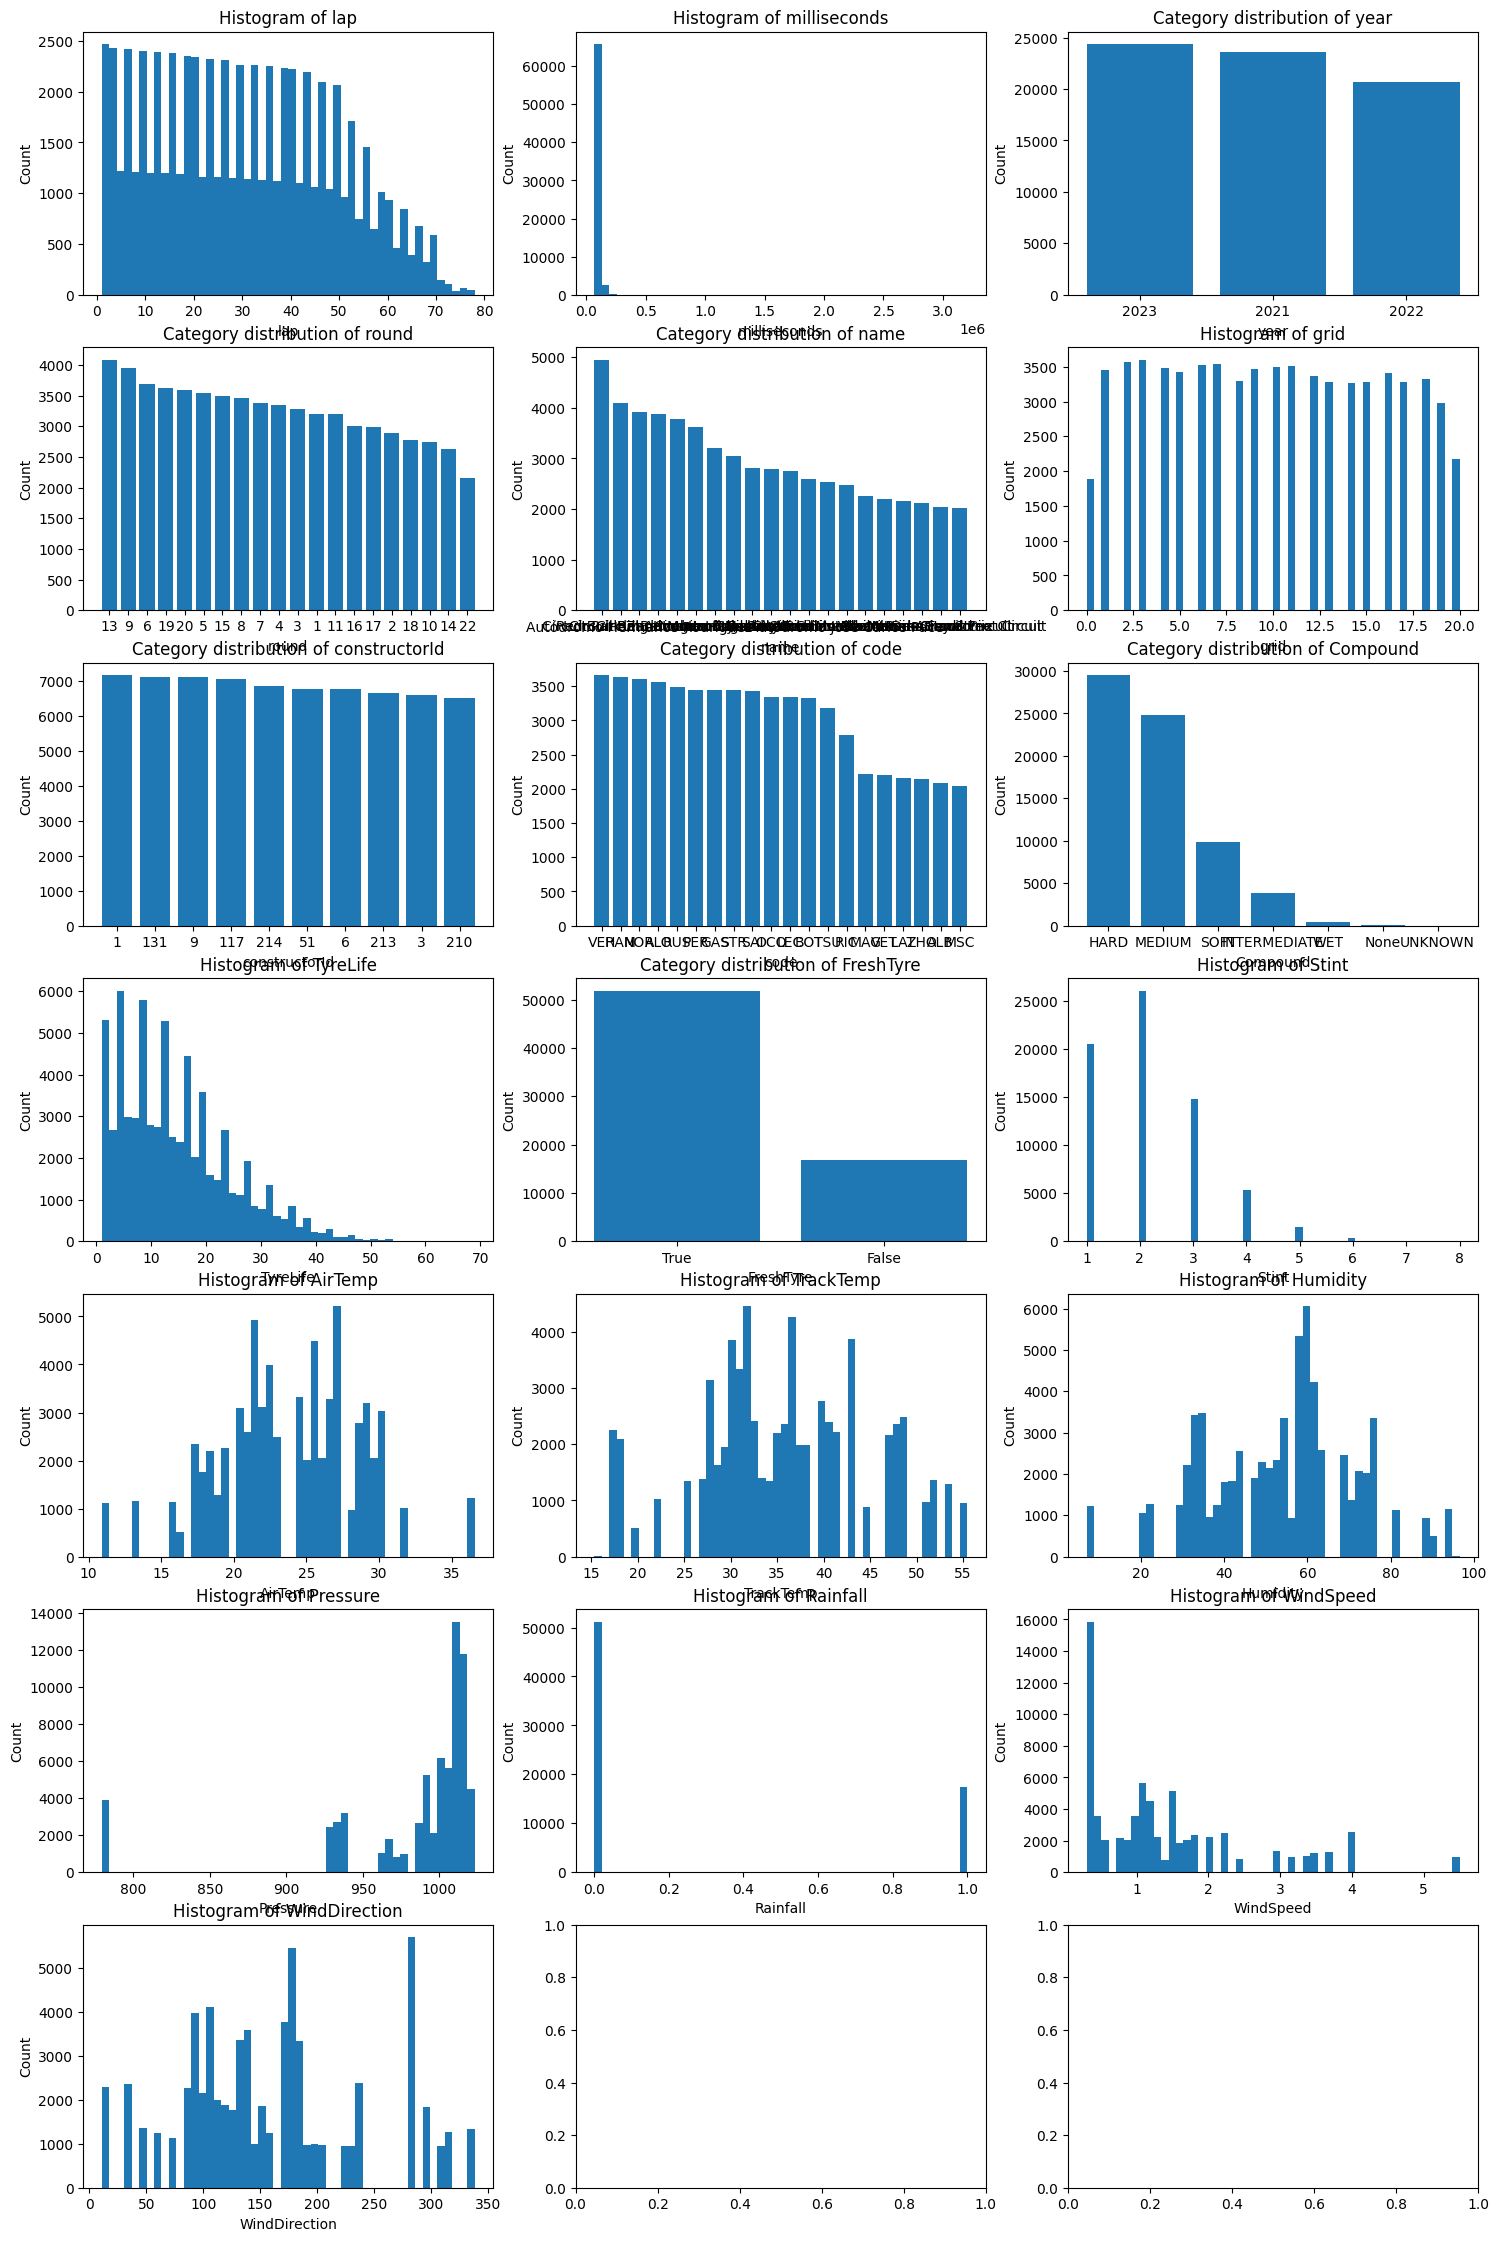

In [ ]:
import matplotlib.pyplot as plt
import math

df_viz = df_model.copy()

cols = df_viz.columns
n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]

    # Numerical feature → histogram
    if df_viz[col].dtype in ["int64", "float64"]:
        ax.hist(df_viz[col].dropna(), bins=50)
        ax.set_title(f"Histogram of {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")

    # Categorical feature → bar plot
    else:
        counts = df_viz[col].value_counts().head(20)
        ax.bar(counts.index.astype(str), counts.values)
        ax.set_title(f"Category distribution of {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")



In [ ]:
df_model["Compound"] = df_model["Compound"].replace(
    {"None": "UNKNOWN", None: "UNKNOWN"}
)


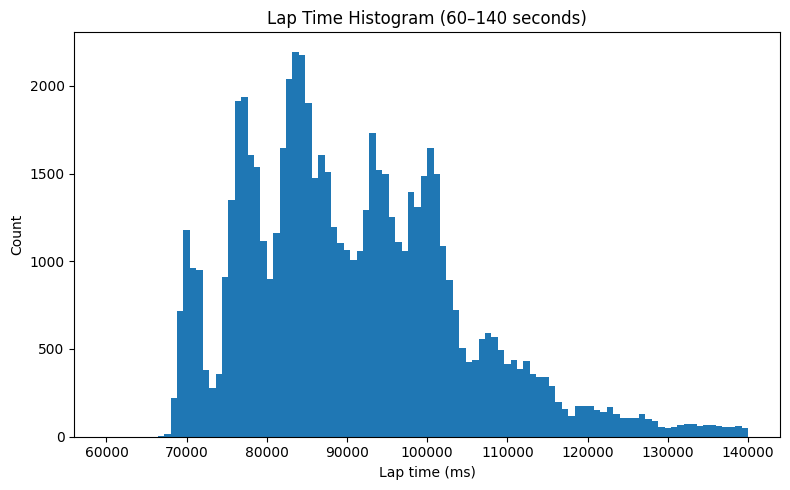

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df_model["milliseconds"], bins=100, range=(60000, 140000))
plt.title("Lap Time Histogram (60–140 seconds)")
plt.xlabel("Lap time (ms)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
q1 = df_model["milliseconds"].quantile(0.25)
q3 = df_model["milliseconds"].quantile(0.75)
iqr = q3 - q1

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)


Q1: 81419.0
Q3: 100200.75
IQR: 18781.75


In [ ]:
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)


Lower bound: 53246.375
Upper bound: 128373.375


In [ ]:

print("Before IQR cleaning:", len(df_model))

df_model = df_model[
    (df_model["milliseconds"] >= lower_bound) &
    (df_model["milliseconds"] <= upper_bound)
].reset_index(drop=True)


print("After IQR cleaning:", len(df_model))



Before IQR cleaning: 68602
After IQR cleaning: 65710


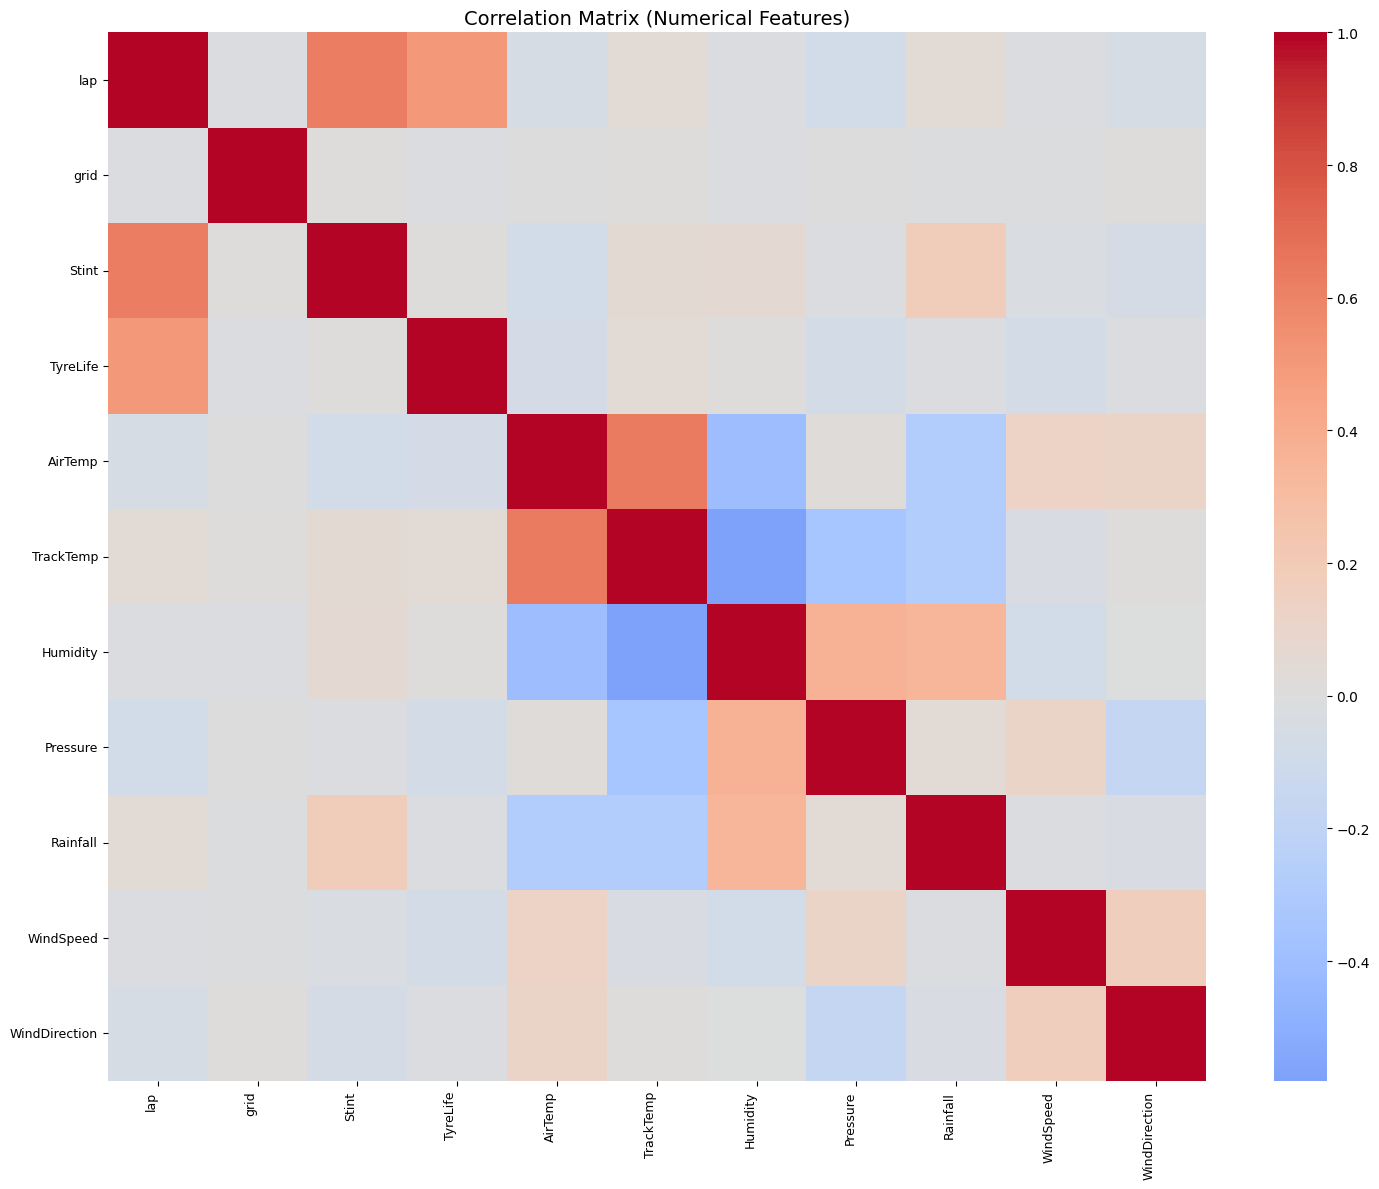

In [ ]:
import seaborn as sns
# Compute correlation matrix
corr = df_model[numerical_features].corr()

# Plot
fig, ax = plt.subplots(figsize=(15, 12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False,
    square=False,
    ax=ax
)

ax.set_title("Correlation Matrix (Numerical Features)", fontsize=14)

# Ticks formatting
ax.tick_params(axis="x", labelsize=9)
ax.tick_params(axis="y", labelsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
#Due to high correlation between Track temperature and Air temperature we will drop AirTemp
df_model = df_model.drop(
    columns=["AirTemp"]
)

# Configuration

In [ ]:
TARGET = "milliseconds"
TEST_YEAR = 2023
RANDOM_STATE = 42

LEAKAGE_COLS = ["position_x", "position_y", "status"]

NUM_FEATS = [
    "lap", "grid", "Stint", "TyreLife",
    "TrackTemp", "Humidity", "Pressure",
    "Rainfall", "WindSpeed", "WindDirection"
]

CAT_FEATS = [
    "round", "name", "constructorId", "code",
    "Compound", "FreshTyre"
]

In [ ]:
df_model = df_model.copy()
df_model = df_model.drop(columns=[c for c in LEAKAGE_COLS if c in df_model.columns], errors="ignore")

df_model["year"] = pd.to_numeric(df_model["year"], errors="coerce").astype("Int64")

missing = [c for c in (NUM_FEATS + CAT_FEATS + ["year", TARGET]) if c not in df_model.columns]
print("Missing columns:", missing)

# Drop rows with missing essentials (adjust if you prefer imputation)
df_model = df_model.dropna(subset=["year", TARGET] + NUM_FEATS + CAT_FEATS)

Missing columns: []


# Train/test split

In [ ]:
train_df = df_model[df_model["year"] < TEST_YEAR].reset_index(drop=True)
test_df  = df_model[df_model["year"] == TEST_YEAR].reset_index(drop=True)

X_train = train_df[NUM_FEATS + CAT_FEATS]
y_train = train_df[TARGET].astype(float)

X_test  = test_df[NUM_FEATS + CAT_FEATS]
y_test  = test_df[TARGET].astype(float)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (42186, 16)
Test shape : (23524, 16)


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUM_FEATS),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), CAT_FEATS),
    ],
    remainder="drop"
)

# Lasso with cross validation

In [ ]:
lasso_selector = Pipeline(steps=[
    ("prep", preprocessor),
    ("lasso", LassoCV(cv=5, n_alphas=100, random_state=RANDOM_STATE, max_iter=20000))
])

lasso_selector.fit(X_train, y_train)

best_alpha = lasso_selector.named_steps["lasso"].alpha_
feature_names = lasso_selector.named_steps["prep"].get_feature_names_out()
coefs = lasso_selector.named_steps["lasso"].coef_

selected_mask = coefs != 0
selected_features = feature_names[selected_mask]

print("\nChosen alpha:", best_alpha)
print(f"Selected features: {selected_mask.sum()} / {len(coefs)}")
print("First 50 selected features:\n", selected_features[:50])


Chosen alpha: 254.74849223457088
Selected features: 25 / 96
First 50 selected features:
 ['num__lap' 'num__grid' 'num__Stint' 'num__TyreLife' 'num__TrackTemp'
 'num__Humidity' 'num__Pressure' 'num__Rainfall' 'num__WindSpeed'
 'num__WindDirection' 'cat__round_13' 'cat__round_17' 'cat__round_9'
 'cat__name_Autódromo José Carlos Pace'
 'cat__name_Bahrain International Circuit' 'cat__name_Baku City Circuit'
 'cat__name_Circuit Park Zandvoort' 'cat__name_Circuit Paul Ricard'
 'cat__name_Circuit de Monaco' 'cat__name_Circuit de Spa-Francorchamps'
 'cat__name_Circuit of the Americas' 'cat__name_Hungaroring'
 'cat__name_Red Bull Ring' 'cat__Compound_INTERMEDIATE'
 'cat__Compound_MEDIUM']


In [ ]:
prep = lasso_selector.named_steps["prep"]  # fitted preprocessor

X_train_p = prep.transform(X_train)
X_test_p  = prep.transform(X_test)

X_train_sel = X_train_p[:, selected_mask]
X_test_sel  = X_test_p[:, selected_mask]

print("Selected train shape:", X_train_sel.shape)
print("Selected test shape :", X_test_sel.shape)

Selected train shape: (42186, 25)
Selected test shape : (23524, 25)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
# Sanity check
assert len(feature_names) == len(coefs)

# Apply the SAME mask used for X_train_sel / X_test_sel
selected_features = feature_names[selected_mask]
selected_coefs = coefs[selected_mask]

# Build a tidy DataFrame
lasso_selected_df = (
    pd.DataFrame({
        "feature": selected_features,
        "coefficient": selected_coefs
    })
    .assign(abs_coef=lambda x: x["coefficient"].abs())
    .sort_values("abs_coef", ascending=False)
    .reset_index(drop=True)
)

lasso_selected_df

,feature,coefficient,abs_coef
0,cat__name_Red Bull Ring,-12580.281172,12580.281172
1,cat__round_17,10569.338566,10569.338566
2,cat__name_Baku City Circuit,8874.175443,8874.175443
3,cat__name_Circuit de Spa-Francorchamps,6034.976795,6034.976795
4,cat__name_Circuit Paul Ricard,5744.270812,5744.270812
5,cat__name_Circuit Park Zandvoort,-5511.940036,5511.940036
6,cat__name_Circuit de Monaco,-5469.074171,5469.074171
7,cat__name_Bahrain International Circuit,4838.748328,4838.748328
8,cat__round_13,-3500.034677,3500.034677
9,cat__Compound_INTERMEDIATE,2741.874729,2741.874729


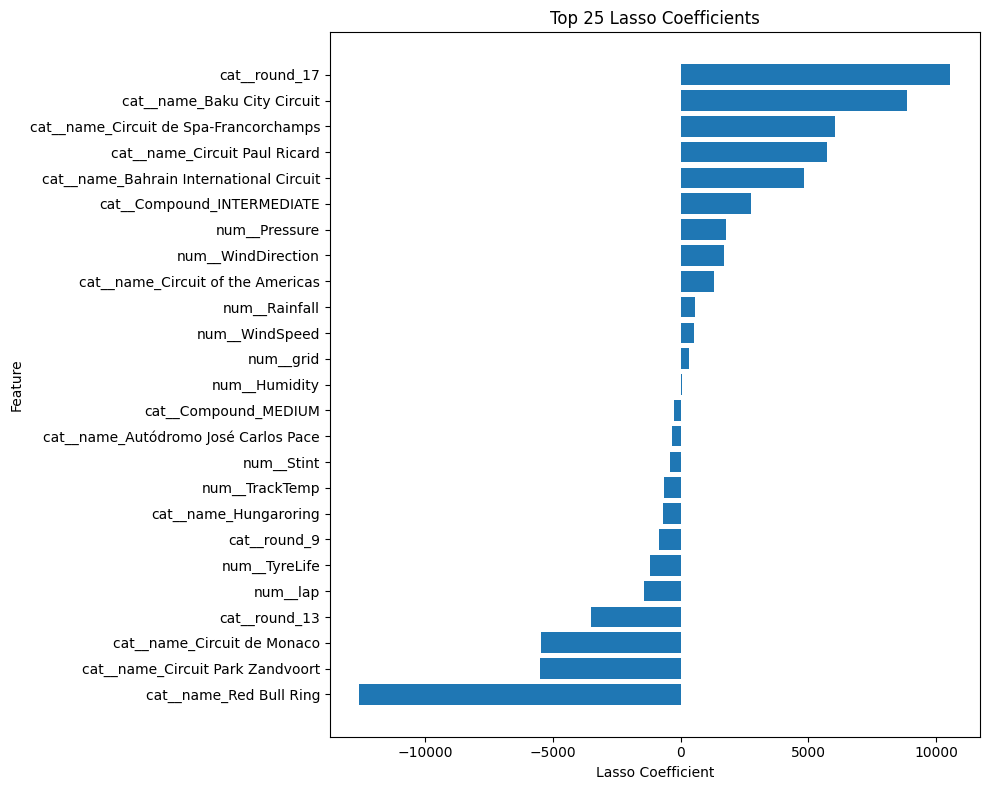

In [ ]:
import matplotlib.pyplot as plt

# Build DataFrame
coef_df = pd.DataFrame({
    "feature": selected_features,
    "coef": selected_coefs
})

# Sort by magnitude and keep top N (optional)
TOP_N = 30
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False).head(TOP_N)

# Sort for horizontal bar plot
coef_df = coef_df.sort_values("coef")

# Plot
plt.figure(figsize=(10, 8))
plt.barh(coef_df["feature"], coef_df["coef"])
plt.xlabel("Lasso Coefficient")
plt.ylabel("Feature")
plt.title(f"Top {len(coef_df)} Lasso Coefficients")
plt.tight_layout()
plt.show()

# Linear regression fit only on selected features

In [ ]:
lr = LinearRegression()
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scores = cross_validate(
    lr,
    X_train_sel,
    y_train,
    cv=cv,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    }
)

print("\nLR CV RMSE:", (-scores["test_rmse"]).mean(), "+/-", (-scores["test_rmse"]).std())
print("LR CV MAE :", (-scores["test_mae"]).mean(),  "+/-", (-scores["test_mae"]).std())
print("LR CV R2  :", (scores["test_r2"]).mean(),     "+/-", (scores["test_r2"]).std())



LR CV RMSE: 6798.744519787222 +/- 76.86793251961365
LR CV MAE : 4236.296083621639 +/- 14.26152317476783
LR CV R2  : 0.7196081161451602 +/- 0.006842800279765143


In [ ]:
lr_final = LinearRegression()
lr_final.fit(X_train_sel, y_train)

y_pred = lr_final.predict(X_test_sel)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("\nTEST RMSE:", rmse)
print("TEST MAE :", mae)
print("TEST R2  :", r2)


TEST RMSE: 9034.201574469838
TEST MAE : 6922.499689366171
TEST R2  : 0.4292289662706117


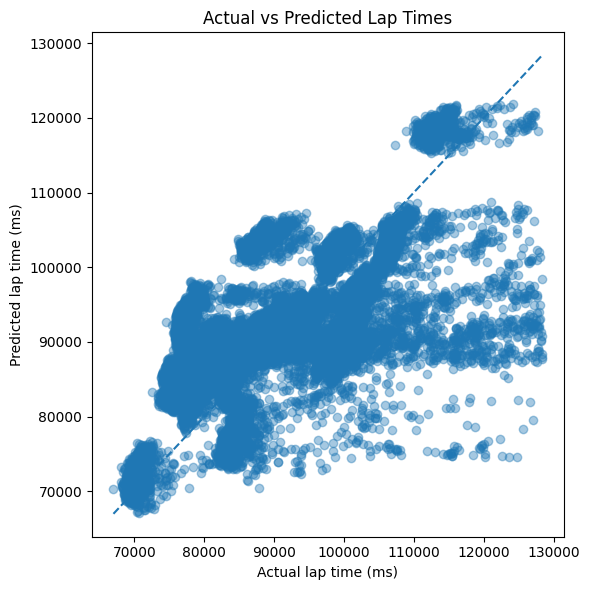

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")
plt.xlabel("Actual lap time (ms)")
plt.ylabel("Predicted lap time (ms)")
plt.title("Actual vs Predicted Lap Times")
plt.tight_layout()
plt.show()

# Log transformations to improve the model

In [ ]:
y_train_log = np.log(y_train)
y_test_log  = np.log(y_test)

lr_log = LinearRegression()
lr_log.fit(X_train_sel, y_train_log)

y_pred_log = lr_log.predict(X_test_sel)
y_pred_log_ms = np.exp(y_pred_log)  # <-- use exp because you used log, not log1p

rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log_ms))
mae_log  = mean_absolute_error(y_test, y_pred_log_ms)
r2_log   = r2_score(y_test, y_pred_log_ms)

print("\nLOG MODEL TEST RMSE:", rmse_log)
print("LOG MODEL TEST MAE :", mae_log)
print("LOG MODEL TEST R2  :", r2_log)


LOG MODEL TEST RMSE: 8882.299145274157
LOG MODEL TEST MAE : 6743.602732610668
LOG MODEL TEST R2  : 0.4482616610182494


# RESIDUAL DIAGNOSTICS

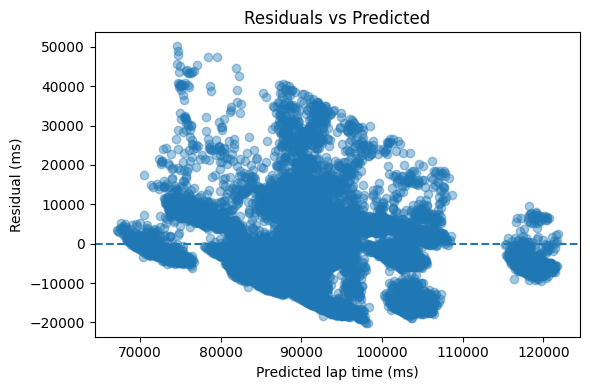

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted lap time (ms)")
plt.ylabel("Residual (ms)")
plt.title("Residuals vs Predicted")
plt.tight_layout()
plt.show()


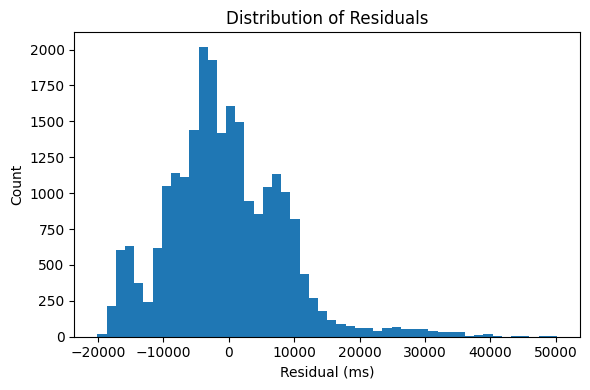

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=50)
plt.xlabel("Residual (ms)")
plt.ylabel("Count")
plt.title("Distribution of Residuals")
plt.tight_layout()
plt.show()


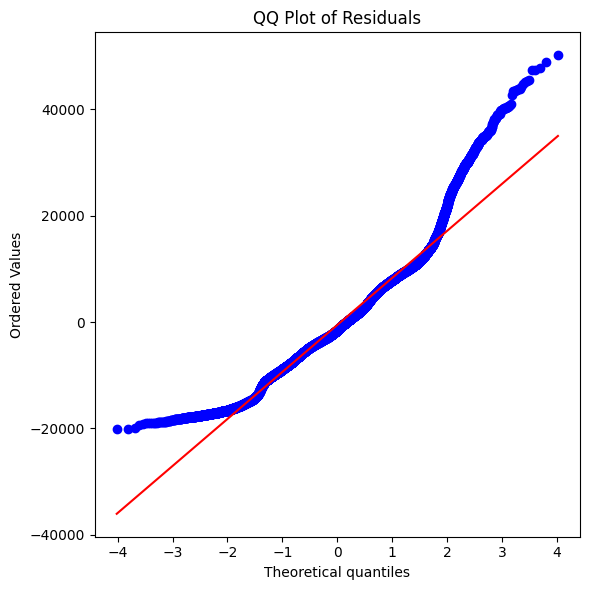

In [ ]:
import scipy.stats as stats

plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot of Residuals")
plt.tight_layout()
plt.show()

In [ ]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, het_white

# Residuals from your final sklearn model
residuals = y_test - y_pred

# Explanatory variables (use test set or train set; test is fine for diagnostics)
X_diag = X_test_sel

# Convert sparse -> dense if needed
X_dense = X_diag.toarray() if hasattr(X_diag, "toarray") else np.asarray(X_diag)

# Add intercept term (required by statsmodels tests)
X_exog = sm.add_constant(X_dense, has_constant="add")

# --- Breusch–Pagan ---
bp_lm, bp_lm_pvalue, bp_f, bp_f_pvalue = het_breuschpagan(residuals, X_exog)
print("Breusch–Pagan:")
print("  LM stat   :", bp_lm)
print("  LM p-value:", bp_lm_pvalue)
print("  F stat    :", bp_f)
print("  F p-value :", bp_f_pvalue)

# --- White ---
wt_lm, wt_lm_pvalue, wt_f, wt_f_pvalue = het_white(residuals, X_exog)
print("\nWhite test:")
print("  LM stat   :", wt_lm)
print("  LM p-value:", wt_lm_pvalue)
print("  F stat    :", wt_f)
print("  F p-value :", wt_f_pvalue)

Breusch–Pagan:
  LM stat   : 2866.787475724397
  LM p-value: 0.0
  F stat    : 155.31353625922324
  F p-value : 0.0

White test:
  LM stat   : 6969.910149959449
  LM p-value: 0.0
  F stat    : 81.43094526799302
  F p-value : 0.0


“Both the Breusch–Pagan and White tests strongly reject the null hypothesis of homoscedasticity, indicating heteroscedastic residuals. This is expected for lap-level racing data and primarily affects statistical inference rather than predictive performance. As the primary objective of this study is prediction, the model’s RMSE and R² remain valid. If coefficient inference were required, heteroscedasticity-robust standard errors would be appropriate.”

In [ ]:
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox

# --- Durbin–Watson ---
dw = durbin_watson(residuals)
print("Durbin–Watson statistic:", dw)

# --- Ljung–Box (autocorrelation up to lag k) ---
lb = acorr_ljungbox(
    residuals,
    lags=[10, 20],
    return_df=True
)

print("\nLjung–Box test:")
print(lb)

Durbin–Watson statistic: 0.4855717303451159

Ljung–Box test:
          lb_stat  lb_pvalue
10   77124.443392        0.0
20  139636.783532        0.0


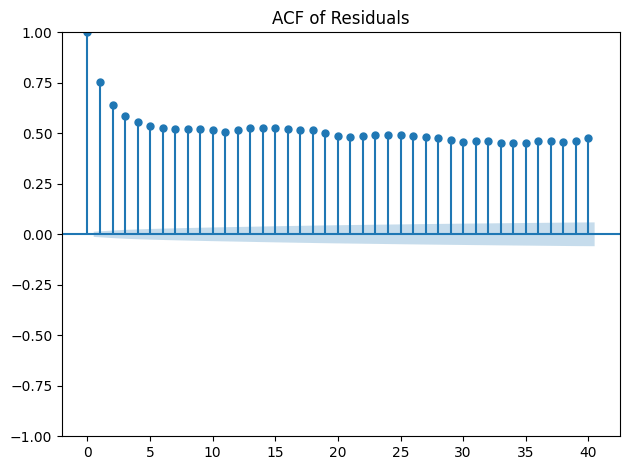

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(residuals, lags=40)
plt.title("ACF of Residuals")
plt.tight_layout()
plt.show()

“The Durbin–Watson statistic and Ljung–Box tests provide strong evidence of positive autocorrelation in the residuals, reflecting the sequential nature of lap-level racing data. This violates the independence assumption of classical linear regression and primarily affects statistical inference rather than predictive performance. Given the focus on prediction, the reported RMSE and R² remain valid, while future work could explore time-series or mixed-effects models to explicitly model serial dependence.”

Residual diagnostics reveal heteroscedasticity and strong autocorrelation, reflecting unmodeled temporal and group-level structure in lap-level data. Since the objective is prediction rather than inference, these violations do not invalidate RMSE or R². Future work could explicitly model serial dependence.